<a href="https://colab.research.google.com/github/djay2806/rock_mine_prediction/blob/main/CatVsDog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p~/.kaggle
!cp kaggle.json ~/.kaggle/

mkdir: invalid option -- '~'
Try 'mkdir --help' for more information.
cp: cannot stat 'kaggle.json': No such file or directory


In [2]:
!kaggle datasets download salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:07<00:00, 147MB/s] 



In [4]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout


In [5]:
import zipfile
zip_ref= zipfile.ZipFile('./dogsvscats.zip','r')
zip_ref.extractall('./content')
zip_ref.close()

In [6]:
train_ds=keras.utils.image_dataset_from_directory(
    directory="/content/content/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)
validation_ds=keras.utils.image_dataset_from_directory(
    directory="/content/content/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [7]:
def process(image,label):
   image = tf.cast(image/255.0 , tf.float32)
   return image,label


In [8]:
train_ds = train_ds.map(process)
validation= validation_ds.map(process)

In [9]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2),padding='valid'))

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2),padding='valid'))

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=(2,2),padding='valid'))

model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,714,625 (14.17 MB)

 Trainable params: 3,714,433 (14.17 MB)

 Non-trainable params: 192 (768.00 B)

In [11]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 69ms/step - accuracy: 0.6348 - loss: 0.7561 - val_accuracy: 0.5954 - val_loss: 33.6048
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.7386 - loss: 0.5267 - val_accuracy: 0.6438 - val_loss: 78.9039
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.7924 - loss: 0.4394 - val_accuracy: 0.7194 - val_loss: 41.6759
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.8314 - loss: 0.3783 - val_accuracy: 0.6812 - val_loss: 56.4513
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.8673 - loss: 0.3120 - val_accuracy: 0.7238 - val_loss: 54.5415
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 66ms/step - accuracy: 0.9057 - loss: 0.2277 - val_accuracy: 0.6826 - val_loss: 37.5315
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.9365 - loss: 0.1592 - val_accuracy: 0.5248 - val_loss: 251.5885
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.9563 - loss: 0

In [13]:
import matplotlib.pyplot as plt

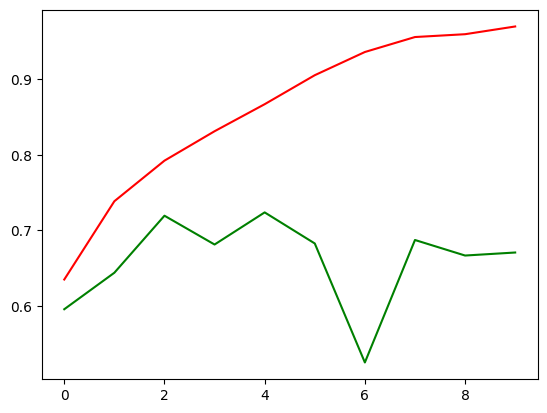

In [14]:
plt.plot(history.history["accuracy"],color="red",label="train")
plt.plot(history.history["val_accuracy"],color="green",label="validation")

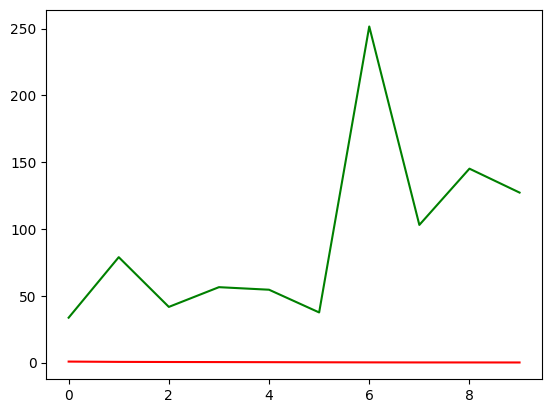

In [15]:
plt.plot(history.history["loss"],color="red",label="train")
plt.plot(history.history["val_loss"],color="green",label="validation")

In [16]:
import cv2

In [22]:
test_img = cv2.imread("/content/content/cat.png")

array([[[ 62,  53,  56],
        [ 72,  62,  68],
        [ 84,  73,  78],
        ...,
        [189, 163, 181],
        [188, 162, 180],
        [187, 161, 180]],

       [[ 65,  53,  59],
        [ 74,  62,  68],
        [ 84,  72,  78],
        ...,
        [189, 163, 179],
        [188, 162, 180],
        [188, 162, 180]],

       [[ 64,  52,  58],
        [ 72,  63,  68],
        [ 85,  73,  79],
        ...,
        [190, 164, 180],
        [189, 163, 180],
        [188, 162, 180]],

       ...,

       [[234, 226, 233],
        [235, 226, 233],
        [235, 227, 234],
        ...,
        [246, 240, 245],
        [246, 240, 245],
        [246, 240, 245]],

       [[234, 226, 233],
        [234, 226, 233],
        [235, 227, 234],
        ...,
        [246, 240, 245],
        [246, 240, 245],
        [246, 240, 245]],

       [[234, 226, 233],
        [234, 226, 233],
        [234, 226, 233],
        ...,
        [246, 240, 245],
        [246, 240, 245],
        [245, 239, 244]]], dtype=uint8)
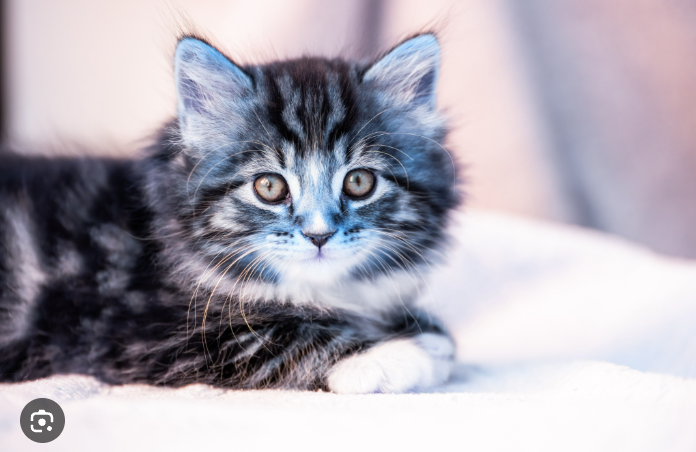

In [23]:
test_img

In [28]:
test_img = cv2.resize(test_img,(256,256))

In [31]:
test_input = test_img.reshape((1,256,256,3))

In [32]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step


array([[0.]], dtype=float32)

In [33]:
test_img = cv2.imread("/content/content/dog.png")

array([[[228, 232, 226],
        [228, 232, 226],
        [227, 231, 225],
        ...,
        [168, 163, 162],
        [169, 168, 166],
        [175, 174, 172]],

       [[227, 231, 226],
        [227, 231, 226],
        [226, 230, 225],
        ...,
        [165, 161, 158],
        [169, 166, 164],
        [175, 171, 170]],

       [[226, 230, 225],
        [226, 230, 225],
        [225, 229, 224],
        ...,
        [163, 159, 155],
        [166, 162, 160],
        [172, 168, 167]],

       ...,

       [[ 93, 197, 150],
        [ 95, 193, 150],
        [101, 201, 157],
        ...,
        [ 49, 104,  82],
        [ 48, 106,  82],
        [ 34,  98,  73]],

       [[ 84, 194, 147],
        [ 89, 193, 149],
        [ 95, 199, 155],
        ...,
        [ 42, 102,  78],
        [ 37, 101,  76],
        [ 29, 100,  73]],

       [[ 70, 192, 144],
        [ 78, 192, 145],
        [ 88, 197, 151],
        ...,
        [ 47, 102,  79],
        [ 43, 102,  79],
        [ 34, 102,  77]]], dtype=uint8)
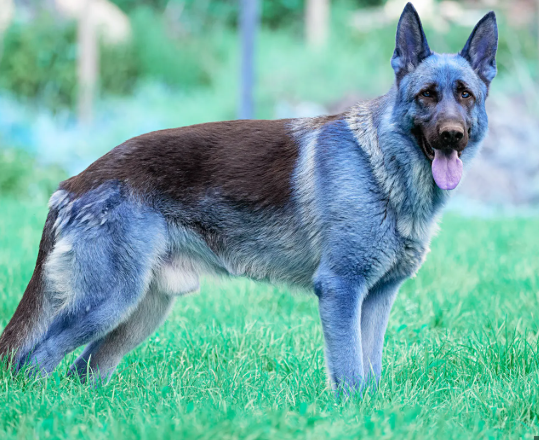

In [34]:
test_img

In [35]:
test_img = cv2.resize(test_img,(256,256))

In [36]:
test_input = test_img.reshape((1,256,256,3))

In [37]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([[1.]], dtype=float32)